In [18]:
#Imports
import pandas as pd
import string
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import numpy as np
import re
from sympy import nextprime
sys.path.append("../src")
from kmodes import KModes

In [2]:
#Import Data

og_df = pd.read_csv("../data/dataset-tickets-multi-lang-4-20k.csv")
og_df.info()
og_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   18539 non-null  object
 1   body      19998 non-null  object
 2   answer    19996 non-null  object
 3   type      20000 non-null  object
 4   queue     20000 non-null  object
 5   priority  20000 non-null  object
 6   language  20000 non-null  object
 7   tag_1     20000 non-null  object
 8   tag_2     19954 non-null  object
 9   tag_3     19905 non-null  object
 10  tag_4     18461 non-null  object
 11  tag_5     13091 non-null  object
 12  tag_6     7351 non-null   object
 13  tag_7     3928 non-null   object
 14  tag_8     1907 non-null   object
dtypes: object(15)
memory usage: 2.3+ MB


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


### Clean and Preprocess Data

In [3]:
#Remove tickets not in english
df = og_df[og_df['language']=="en"]
df = df.drop(columns='language')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 11923 entries, 1 to 19997
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   10891 non-null  object
 1   body      11922 non-null  object
 2   answer    11920 non-null  object
 3   type      11923 non-null  object
 4   queue     11923 non-null  object
 5   priority  11923 non-null  object
 6   tag_1     11923 non-null  object
 7   tag_2     11913 non-null  object
 8   tag_3     11879 non-null  object
 9   tag_4     11050 non-null  object
 10  tag_5     7885 non-null   object
 11  tag_6     4538 non-null   object
 12  tag_7     2565 non-null   object
 13  tag_8     1327 non-null   object
dtypes: object(14)
memory usage: 1.4+ MB


,subject,body,answer,type,queue,priority,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN
5,Concerns About Securing Medical Data on 2-in-1...,Inquiring about best practices for securing me...,Thank you for your concern regarding securing ...,Request,Technical Support,medium,Security,Product,Feature,IT,Tech Support,NaN,NaN,NaN
7,Problem with Integration,"The integration stopped working unexpectedly, ...",I will look into the problem and call you at <...,Problem,IT Support,high,Technical,Integration,Bug,Resolution,Outage,Documentation,NaN,NaN


In [4]:
# df.isnull().sum()
df = df.drop(columns=['tag_6', 'tag_7', 'tag_8'])
df.isnull().sum()

subject     1032
body           1
answer         3
type           0
queue          0
priority       0
tag_1          0
tag_2         10
tag_3         44
tag_4        873
tag_5       4038
dtype: int64

In [5]:
def clean_text(text):
    if pd.isnull(text):
        return "" 
    text = text.lower() 
    text = re.sub(r'[^a-z\s]', '', text)  # Remove everything except letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # change multiple spaces into one
    return text

In [6]:
df = df.dropna(subset=['body', 'answer'])
df['body'] = df['body'].apply(clean_text)
tag_columns = ['tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5']
df[tag_columns] = df[tag_columns].fillna('Unknown')
df = df.drop(columns='subject')
df.isnull().sum()

body        0
answer      0
type        0
queue       0
priority    0
tag_1       0
tag_2       0
tag_3       0
tag_4       0
tag_5       0
dtype: int64

In [7]:
#Check for weird values
for col in df:
    num_unique = df[col].nunique()
    print(col, num_unique)

print(df['type'].unique())
print(df['queue'].unique())
print(df['priority'].unique())

body 11909
answer 11919
type 4
queue 10
priority 3
tag_1 87
tag_2 177
tag_3 298
tag_4 401
tag_5 478
['Request' 'Problem' 'Incident' 'Change']
['Customer Service' 'Technical Support' 'IT Support' 'Product Support'
 'Billing and Payments' 'Service Outages and Maintenance'
 'Human Resources' 'Returns and Exchanges' 'Sales and Pre-Sales'
 'General Inquiry']
['medium' 'high' 'low']


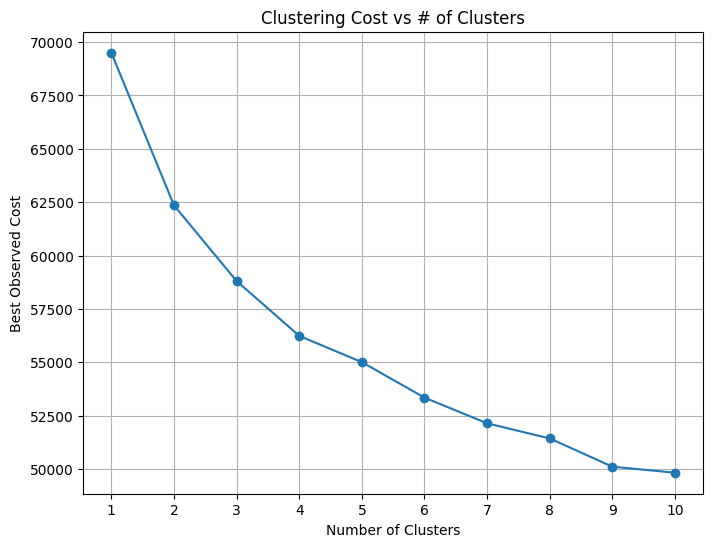

In [8]:
clustering_df = df.drop(columns=['body', 'answer'])
results = []
for k in range(1,11):
    costs = []
    for _ in range(10):
        kmode = KModes(k, clustering_df)
        costs.append(kmode.get_cost())

    results.append(min(costs))

    
k_values = list(range(1, 11))
plt.figure(figsize=(8, 6))
plt.plot(k_values, results, marker='o', linestyle='-')


plt.xlabel("Number of Clusters")
plt.ylabel("Best Observed Cost")
plt.title("Clustering Cost vs # of Clusters")
plt.xticks(k_values)  
plt.grid(True)
plt.show()

In [9]:
import numpy as np
best_cost = np.inf

for _ in range(10):
    kmode = KModes(6, clustering_df)
    cost = kmode.get_cost()
    if cost < best_cost:
        best_cost = cost
        clusters = kmode.get_clusters()

In [13]:
cluster_data =[]
for clust in clusters:
    cluster_data.append(clustering_df.iloc[clust.get_data(), :])

cluster_data[0].head()

,type,queue,priority,tag_1,tag_2,tag_3,tag_4,tag_5
16993,Change,Product Support,medium,Security,Compliance,IT,Tech Support,Unknown
1,Request,Customer Service,medium,Feedback,Sales,IT,Tech Support,Unknown
4,Request,Customer Service,medium,Security,Customer,Compliance,Breach,Documentation
16,Change,Product Support,low,Feature,IT,Tech Support,Unknown,Unknown
22,Request,Billing and Payments,medium,Security,Documentation,IT,Tech Support,Unknown


In [14]:
tag_cols = ['tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5']

for i, cluster_df in enumerate(cluster_data):
    print(f"\n--- Cluster {i} Tag Counts ---")
    for tag in range(len(tag_cols)):
        print(f"\n{tag} value counts:")
        print(cluster_df.iloc[:,tag].value_counts())


--- Cluster 0 Tag Counts ---

0 value counts:
type
Request     1548
Problem      647
Change       493
Incident     472
Name: count, dtype: int64

1 value counts:
queue
Product Support                    1180
Customer Service                    653
Billing and Payments                517
IT Support                          209
Returns and Exchanges               161
Technical Support                   161
Sales and Pre-Sales                 117
Human Resources                      77
General Inquiry                      53
Service Outages and Maintenance      32
Name: count, dtype: int64

2 value counts:
priority
medium    1932
low        804
high       424
Name: count, dtype: int64

3 value counts:
tag_1
Security                                                  1142
Feedback                                                   533
Feature                                                    365
Billing                                                    246
Customer                         

In [15]:
cluster_df.head()

,type,queue,priority,tag_1,tag_2,tag_3,tag_4,tag_5
13980,Change,Technical Support,high,Security,Data Protection,IT,Tech Support,Unknown
38,Request,Technical Support,low,Feedback,Sales,IT,Tech Support,Unknown
86,Problem,Technical Support,low,Security,Virus,IT,Tech Support,Performance
106,Request,Technical Support,high,Customer,Strategy,Magento,DigitalMarketing,Growth
113,Request,Technical Support,high,Security,Network,Compliance,Performance,IT


/tmp/ipykernel_101664/170624988.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_tags.keys(), rotation=45)
/tmp/ipykernel_101664/170624988.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_tags.keys(), rotation=45)
/tmp/ipykernel_101664/170624988.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_tags.keys(), rotation=45)
/tmp/ipykernel_101664/170624988.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_tags.keys(), rotation=45)
/tmp/ipykernel_101664/170624988.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of tick

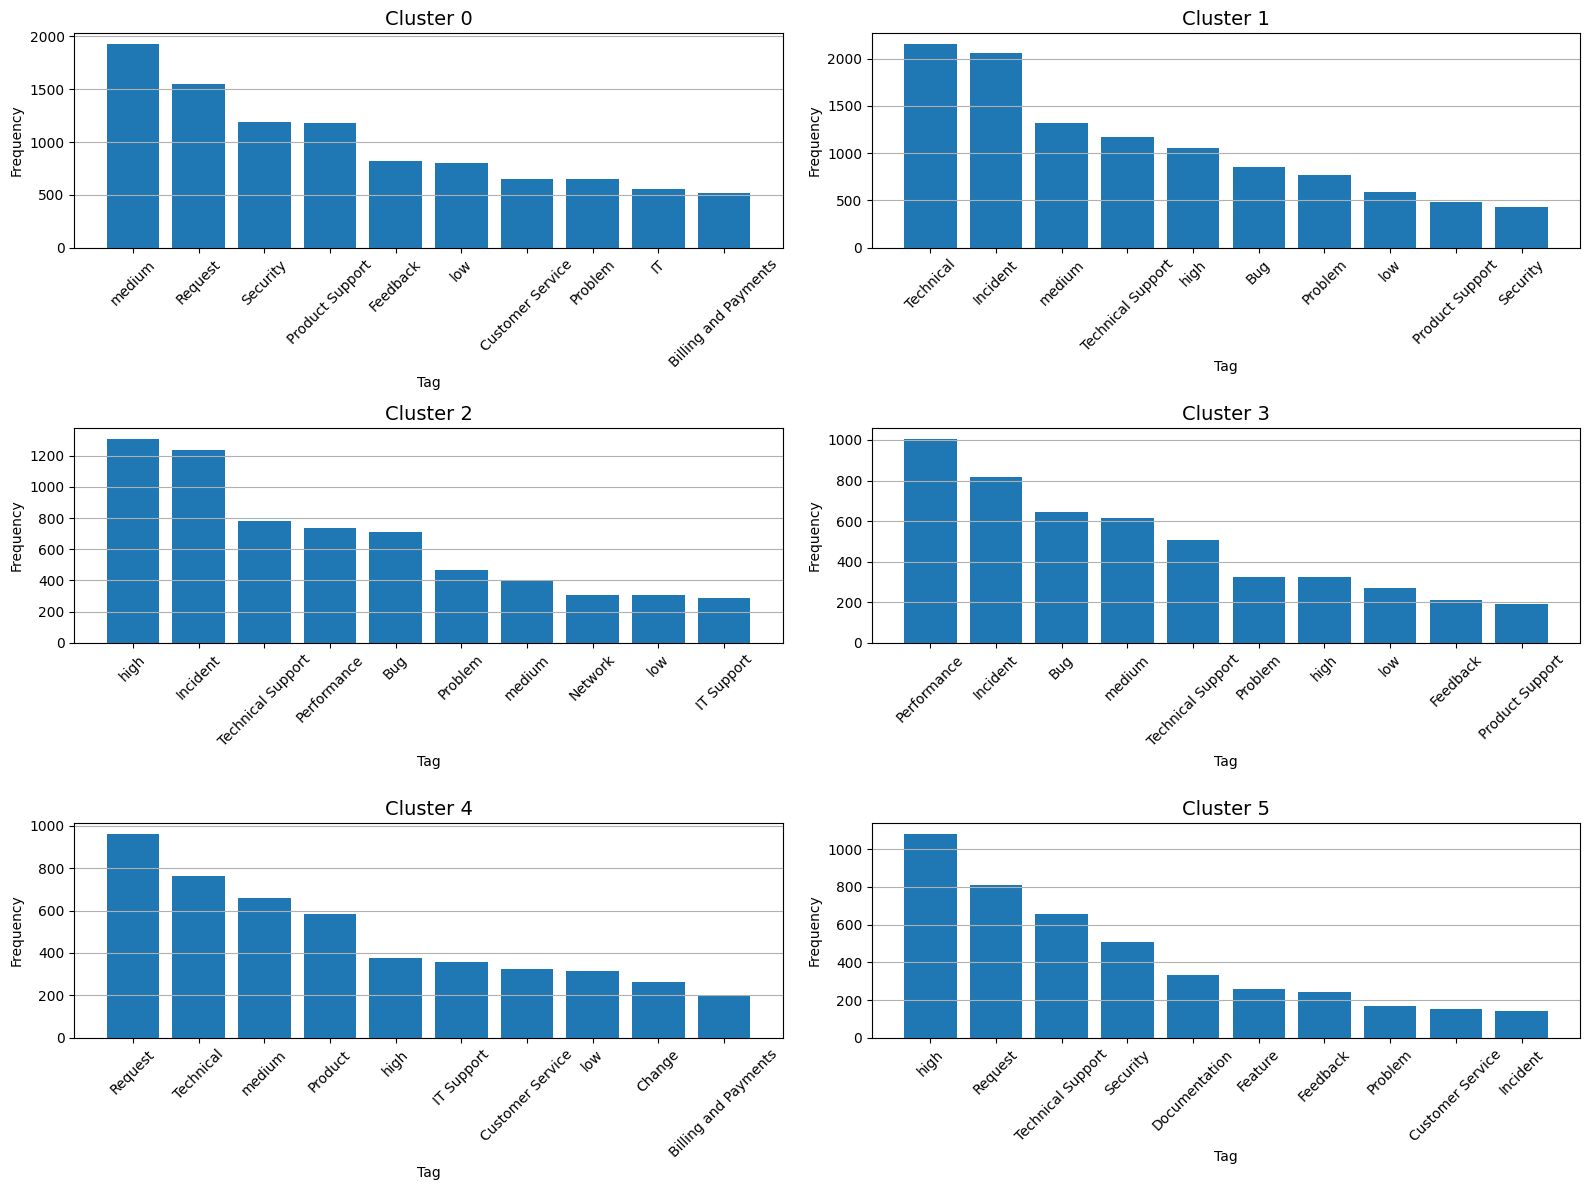

In [16]:
#Barchart for top tags in each cluster

tag_cols = ['tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5']

fig, axes = plt.subplots(3, 2, figsize=(16, 12)) 
axes = axes.flatten()

for i, cluster_df in enumerate(cluster_data):
    tag_total = {}
    for tag in range(len(tag_cols)):
        counts = cluster_df.iloc[:, tag].value_counts()
        for tag_value, count in counts.items():
            if tag_value not in tag_total:
                tag_total[tag_value] = 0
            tag_total[tag_value] += count
    tag_total.pop('Unknown', None)

    sorted_tags = dict(sorted(tag_total.items(), key=lambda item: item[1], reverse=True)[:10])

    ax = axes[i] 
    ax.bar(sorted_tags.keys(), sorted_tags.values())
    ax.set_title(f'Cluster {i}', fontsize=14)
    ax.set_xlabel('Tag')
    ax.set_ylabel('Frequency')
    ax.set_xticklabels(sorted_tags.keys(), rotation=45)
    ax.grid(axis='y')
plt.tight_layout()
plt.show()


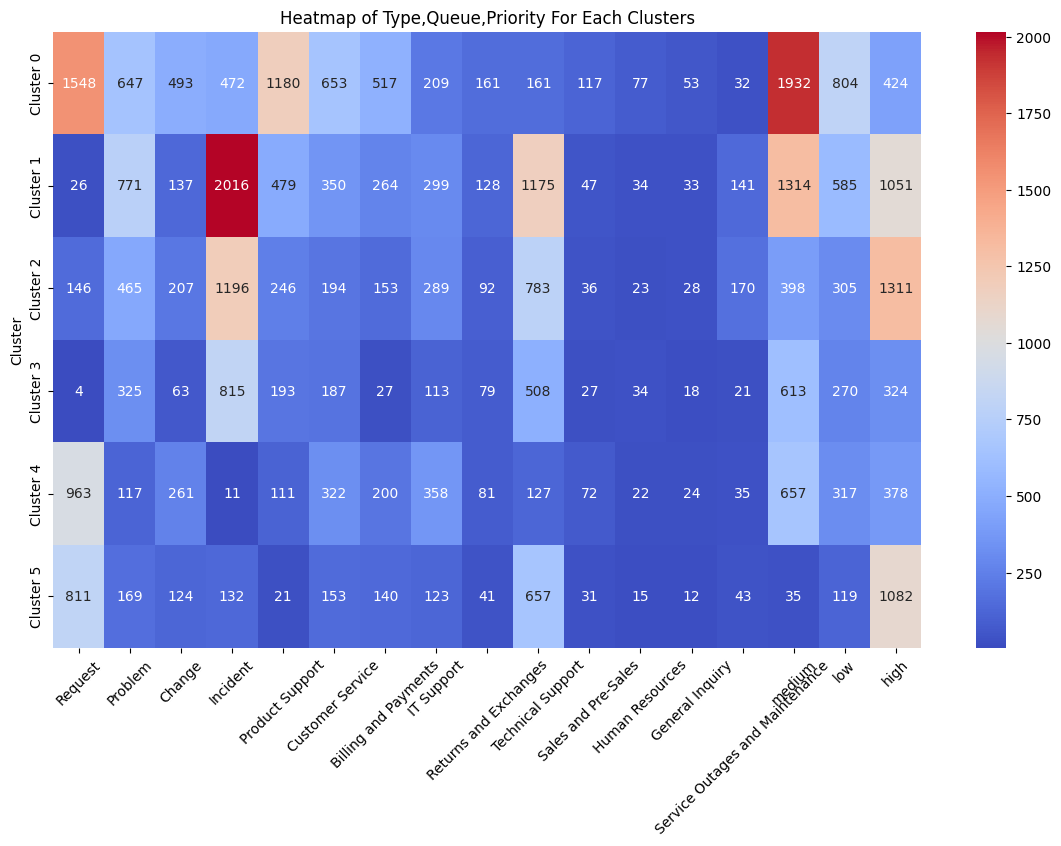

In [17]:
#plot for heatmap
cols = ['type', 'queue', 'priority']
all_counts = []

for cluster_df in cluster_data:
    total = {}
    for col in range(len(cols)):
        counts = cluster_df.iloc[:, col].value_counts()
        for value, count in counts.items():
            if value not in total:
                total[value] = 0
                total[value] += count
    
    all_counts.append(total)

heat_df = pd.DataFrame(all_counts).fillna(0)
heat_df.index = [f'Cluster {i}' for i in range(len(cluster_data))]

plt.figure(figsize=(14,8))
sns.heatmap(heat_df, cmap='coolwarm', annot=True, fmt='.0f')
plt.title('Heatmap of Type,Queue,Priority For Each Clusters')
plt.ylabel('Cluster')
plt.xticks(rotation=45)
plt.show()


In [28]:
def get_k_shingles_from_document(k, document):
    shingles = set()
    for i in range(len(document) - k + 1):
        shingles.add(document[i:i+k])
    return shingles

def create_characteristic_matrix(docs, k):
    shingle_sets = []
    all_shingles = set()

    # Generate shingle sets for each document
    for doc in docs:
        shingles = get_k_shingles_from_document(k, doc)
        shingle_sets.append(shingles)
        all_shingles.update(shingles)

    all_shingles = list(all_shingles)  # freeze set to list

    # Build full data array first (list of lists)
    matrix_data = []
    for shingles in shingle_sets:
        row = [1 if shingle in shingles else 0 for shingle in all_shingles]
        matrix_data.append(row)

    # Transpose: each row should be a shingle, each column a doc
    matrix_data = np.array(matrix_data).T

    # Build the DataFrame once at the end
    characteristic_matrix = pd.DataFrame(
        matrix_data,
        index=all_shingles
    )

    return characteristic_matrix

def generateSignatureMatrix(characterisitcMatrix, num_hashes):

    # Initing signature matrix
    sig_matrix = np.full([num_hashes, len(characterisitcMatrix.columns)], fill_value=np.inf)

    # h(row) = (A*row + B) % P
    Ahash = np.random.choice(range(0,10000), size=num_hashes) 
    Bhash = np.random.choice(range(0,10000), size=num_hashes)
    Phash = nextprime(characterisitcMatrix.shape[0]) # Getting a prime number greater than the number of rows in characteristic matrix

    for r in range(len(characterisitcMatrix)): # looping through rows of characteristic matrix
        hashvals = (Ahash * r + Bhash) % Phash # Generating list of hash values

        # Filling in each documents column of the signature matrix 
        for doc in range(len(characterisitcMatrix.columns)):
            if characterisitcMatrix.iloc[r,doc] == 1:
                sig_matrix[:,doc] = np.minimum(sig_matrix[:,doc], hashvals) # Choosing the min of the hash value or the signature matrix for each row of the signature matrix
    

    return sig_matrix

In [20]:
def find_top_k_similar(docs, row_numbers, new_doc, k_shingle=5, num_hashes=100, top_k=5):

    # Combine the new doc and existing docs into one list
    docs_to_compare = [new_doc] + list(docs)

    # Create characteristic and signature matrices
    char_matrix = create_characteristic_matrix(docs_to_compare, k_shingle)
    sig_matrix = generateSignatureMatrix(char_matrix, num_hashes)

    # Target vector is the first column (the new doc)
    target_vector = sig_matrix[:, 0]

    # Compare target to all other docs
    similarities = [
        sum(target_vector == sig_matrix[:, i]) / sig_matrix.shape[0]
        for i in range(1, sig_matrix.shape[1])
    ]

    # Zip similarities with original row numbers
    results = list(zip(row_numbers, similarities))

    # Sort by similarity descending
    results = sorted(results, key=lambda x: x[1], reverse=True)

    # Return top_k results
    return results[:top_k]

def predict_cluster(kmodes_model, new_row):
    centroids = kmodes_model.get_centroids()
    
    closest_cluster = 0
    closest_dist = kmodes_model._dist(centroids[0], new_row)

    for i, centroid in enumerate(centroids):
        d = kmodes_model._dist(centroid, new_row)
        if d < closest_dist:
            closest_cluster = i
            closest_dist = d

    return closest_cluster

In [29]:
new_row = [
    "Incident",     # type
    "Technical Support",  # queue
    "high",         # priority
    "Technical",    # tag_1
    "Bug",          # tag_2
    "Performance",  # tag_3
    "Unknown",      # tag_4
    "Unknown"       # tag_5
]

new_ticket_body = (
    "unable to access the analytics dashboard after the software update "
    "tried restarting the server and clearing the cache but the issue remains "
    "need urgent support to resolve the crash"
)

# Predict which cluster the new ticket belongs to
predicted_cluster_idx = predict_cluster(kmode, new_row)
print(f"New ticket assigned to cluster {predicted_cluster_idx}")

# Get the list of row numbers from the predicted cluster
cluster_row_numbers = clusters[predicted_cluster_idx].get_data()  # List of row indices

# Fetch the bodies corresponding to those row numbers
docs_in_cluster = df.iloc[cluster_row_numbers]['body'].fillna('').tolist()

# Run MinHashing to find the top 5 most similar tickets
top_matches = find_top_k_similar(
    docs_in_cluster,
    cluster_row_numbers,
    new_ticket_body,
    k_shingle=5,
    num_hashes=100,
    top_k=5
)

# Print the matches
print("\nTop 5 most similar tickets in the cluster:")
for i, (row_num, sim_score) in enumerate(top_matches, 1):
    print(f"Match #{i}: Row {row_num} with similarity {sim_score:.3f}")


New ticket assigned to cluster 0

Top 5 most similar tickets in the cluster:
Match #1: Row 6286 with similarity 0.210
Match #2: Row 11159 with similarity 0.210
Match #3: Row 3670 with similarity 0.190
Match #4: Row 9975 with similarity 0.180
Match #5: Row 5722 with similarity 0.170


In [31]:
# Print the new ticket body
print("\nNew Ticket Body:\n")
print(new_ticket_body)

# Print the bodies and answers of the top 5 most similar past tickets
print("\nSuggested Similar Tickets:\n")
for i, (row_pos, sim_score) in enumerate(top_matches, 1):
    try:
        ticket_body = df.iloc[row_pos]['body']
        ticket_answer = df.iloc[row_pos]['answer']
    except IndexError:
        ticket_body = "[Body not found]"
        ticket_answer = "[Resolution not found]"

    print(f"Match #{i} — Row {row_pos} — Similarity: {sim_score:.3f}")
    print("Ticket Body:\n", ticket_body)
    print("Resolution:\n", ticket_answer)
    print('-' * 100)



New Ticket Body:

unable to access the analytics dashboard after the software update tried restarting the server and clearing the cache but the issue remains need urgent support to resolve the crash

Suggested Similar Tickets:

Match #1 — Row 6286 — Similarity: 0.210
Ticket Body:
 hello i encountered a problem with my investment analytics dashboard as it has crashed i believe it might be due to a recent database update that is not compatible after attempting to restart the system and reviewing the database logs the issue still hasnt been resolved could you provide assistance
Resolution:
 I would be glad to assist with the issue concerning your investment analytics dashboard. In order to better understand and address the problem, could you please share the specific error message you are encountering along with details about the recent database update? If necessary, we can arrange a call at a convenient time to discuss this further and find a solution. Please let me know a suitable time